<a href="https://colab.research.google.com/github/tobiasllop/Tesis/blob/main/Parte_B_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Parte B - Tesis Tobias Llop

---
**Disclaimer:** siguiente notebook utiliza muchas tecnicas de chunking y almacenamiento intermedo de dataframes para optimizar la Memoria RAM del entorno gratuito de colab.


In [2]:
!pip install prince
!pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.3/197.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 61.2 MB/s eta 0:00:00


# Data Loading Deudas Enero 2026

In [1]:
import pandas as pd
import gc
import fastparquet

# 1. Cargar catálogo
ruta_entidades = '/content/drive/MyDrive/Tesis2026/EntidadesFinancierasBCRA.csv'
entidades = pd.read_csv(ruta_entidades)[['cod_entidad', 'grupo_entidad']]
entidades['cod_entidad'] = entidades['cod_entidad'].astype(str).str.zfill(5)

# 2. Cargar y procesar deudores
ruta_deudores_26 = '/content/drive/MyDrive/Tesis2026/deudores_final_enero.parquet'
chunks_list = []

try:
    parquet_file = fastparquet.ParquetFile(ruta_deudores_26)
    for i, chunk in enumerate(parquet_file.iter_row_groups(columns=['cod_entidad', 'tipo_id', 'nro_id', 'prestamos'])):
        chunk = chunk[chunk['tipo_id'] == '11'].copy()
        if not chunk.empty:
            chunk = chunk.rename(columns={'nro_id': 'cuit', 'prestamos': 'deuda_total'})
            chunk['cuit'] = chunk['cuit'].astype(str)
            chunk['cod_entidad'] = chunk['cod_entidad'].astype(str).str.zfill(5)
            chunk = pd.merge(chunk, entidades, on='cod_entidad', how='left')
            chunks_list.append(chunk[['cuit', 'deuda_total', 'grupo_entidad']])
        if i % 100 == 0: gc.collect()

    df_2026 = pd.concat(chunks_list, ignore_index=True)

    # Clasificar y obtener cortes
    df_2026['Tamanio_Deuda'], bins = pd.qcut(df_2026['deuda_total'], q=4, labels=['Muy Pequeña', 'Pequeña', 'Mediana', 'Grande'], retbins=True)
    print(f"Cortes de Deuda: {bins}")

    # Guardar archivo intermedio y limpiar
    ruta_intermedia_deuda = '/content/drive/MyDrive/Tesis2026/deudas_enero_2026_Categoricas.parquet'
    df_2026[['cuit', 'grupo_entidad', 'Tamanio_Deuda']].to_parquet(ruta_intermedia_deuda, index=False)
    print(f"Archivo de deudas guardado en: {ruta_intermedia_deuda}")

    del df_2026, chunks_list
    gc.collect()
except Exception as e:
    print(f"Error: {e}")

Cortes de Deuda: [0.00000000e+00 1.50000000e+02 5.39000000e+02 1.63700000e+03
 6.96279749e+08]
Archivo de deudas guardado en: /content/drive/MyDrive/Tesis2026/deudas_enero_2026_Categoricas.parquet


# Data Loading - Padron Fisicas Enero 2026

In [ ]:
import pandas as pd
import numpy as np
import gc
import fastparquet

ruta_padron = '/content/drive/MyDrive/Tesis2026/padron_fisicas_enero.parquet'
chunks_finales = []

try:
    pf = fastparquet.ParquetFile(ruta_padron)
    cols = ['cuit', 'sexo', 'fecha_nacimiento', 'provincia', 'codigo_postal', 'fecha_fallecimiento']

    for i, chunk in enumerate(pf.iter_row_groups(columns=cols)):
        # Limpieza: se excluye explícitamente el género 'X'
        chunk['fecha_nacimiento'] = pd.to_datetime(chunk['fecha_nacimiento'], errors='coerce')
        mask = (chunk['fecha_fallecimiento'] == '') & (chunk['sexo'] != '') & (chunk['sexo'] != 'X')
        chunk = chunk[mask].copy()
        if chunk.empty: continue

        # Ingeniería de atributos
        chunk['Rango_Etario'] = pd.cut(2026 - chunk['fecha_nacimiento'].dt.year, bins=[17, 25, 40, 65, 120], labels=['Jóvenes', 'Adultos_Ins', 'Adultos_Cons', 'Adultos_May'])

        prov = pd.to_numeric(chunk['provincia'], errors='coerce').fillna(-1)
        cp = pd.to_numeric(chunk['codigo_postal'], errors='coerce').fillna(-1)

        condiciones = [
            (prov == 0),
            (prov == 1) & (cp.between(1600, 1900))
        ]
        opciones = ['CABA', 'AMBA']
        chunk['Region'] = np.select(condiciones, opciones, default='Interior')

        chunk = chunk[['cuit', 'sexo', 'Rango_Etario', 'Region']].rename(columns={'sexo': 'Genero'})
        chunk['cuit'] = chunk['cuit'].astype(str)
        chunks_finales.append(chunk)

        if i % 100 == 0:
            gc.collect()

    df_padron_procesado = pd.concat(chunks_finales, ignore_index=True)

    ruta_intermedia_padron = '/content/drive/MyDrive/Tesis2026/padron_categorico_enero_2026.parquet'
    df_padron_procesado.to_parquet(ruta_intermedia_padron, index=False)
    print(f"Archivo de padrón (sin Género X) guardado en: {ruta_intermedia_padron}")

    del df_padron_procesado, chunks_finales
    gc.collect()
except Exception as e:
    print(f"Error: {e}")

# Celda 2: Merge

In [ ]:
!pip install polars
import polars as pl
import pandas as pd
import gc
import os

ruta_deuda = '/content/drive/MyDrive/Tesis2026/deudas_enero_2026_Categoricas.parquet'
ruta_padron = '/content/drive/MyDrive/Tesis2026/padron_categorico_enero_2026.parquet'
ruta_mca_final = '/content/drive/MyDrive/Tesis2026/df_mca_2026_final.parquet'

# Borrar si ya existe para empezar limpio
if os.path.exists(ruta_mca_final): os.remove(ruta_mca_final)

print("Iniciando Join ultra-eficiente con Polars (Lazy Engine)...")

# Escaneamos los archivos
d_lazy = pl.scan_parquet(ruta_deuda)
p_lazy = pl.scan_parquet(ruta_padron)

for digito in range(10):
    print(f"Procesando fragmento CUIT termina en {digito}...      ", end='\r')

    filtro = pl.col('cuit').str.ends_with(str(digito))

    fragmento_join = (
        d_lazy.filter(filtro)
        .join(p_lazy.filter(filtro), on='cuit', how='inner')
        .drop('cuit')
        .drop_nulls()
        .collect()
    )

    if fragmento_join.height > 0:
        df_temp = fragmento_join.to_pandas()
        for col in df_temp.columns:
            df_temp[col] = df_temp[col].astype('category')

        if not os.path.exists(ruta_mca_final):
            df_temp.to_parquet(ruta_mca_final, engine='fastparquet', index=False)
        else:
            df_temp.to_parquet(ruta_mca_final, engine='fastparquet', append=True, index=False)

        del df_temp

    del fragmento_join
    gc.collect()

# Liberar punteros lazy antes de la carga final
del d_lazy, p_lazy
gc.collect()

print("\n¡Proceso finalizado con Polars! Cargando resultado final...")
df_mca_2026 = pd.read_parquet(ruta_mca_final)
print(f"Registros totales consolidados: {len(df_mca_2026)}")
display(df_mca_2026.info())
display(df_mca_2026.head())

# Celda 3: Análisis Estadístico y Gráficos

Cargando dataset consolidado desde Drive...
Calculando frecuencias para los gráficos...


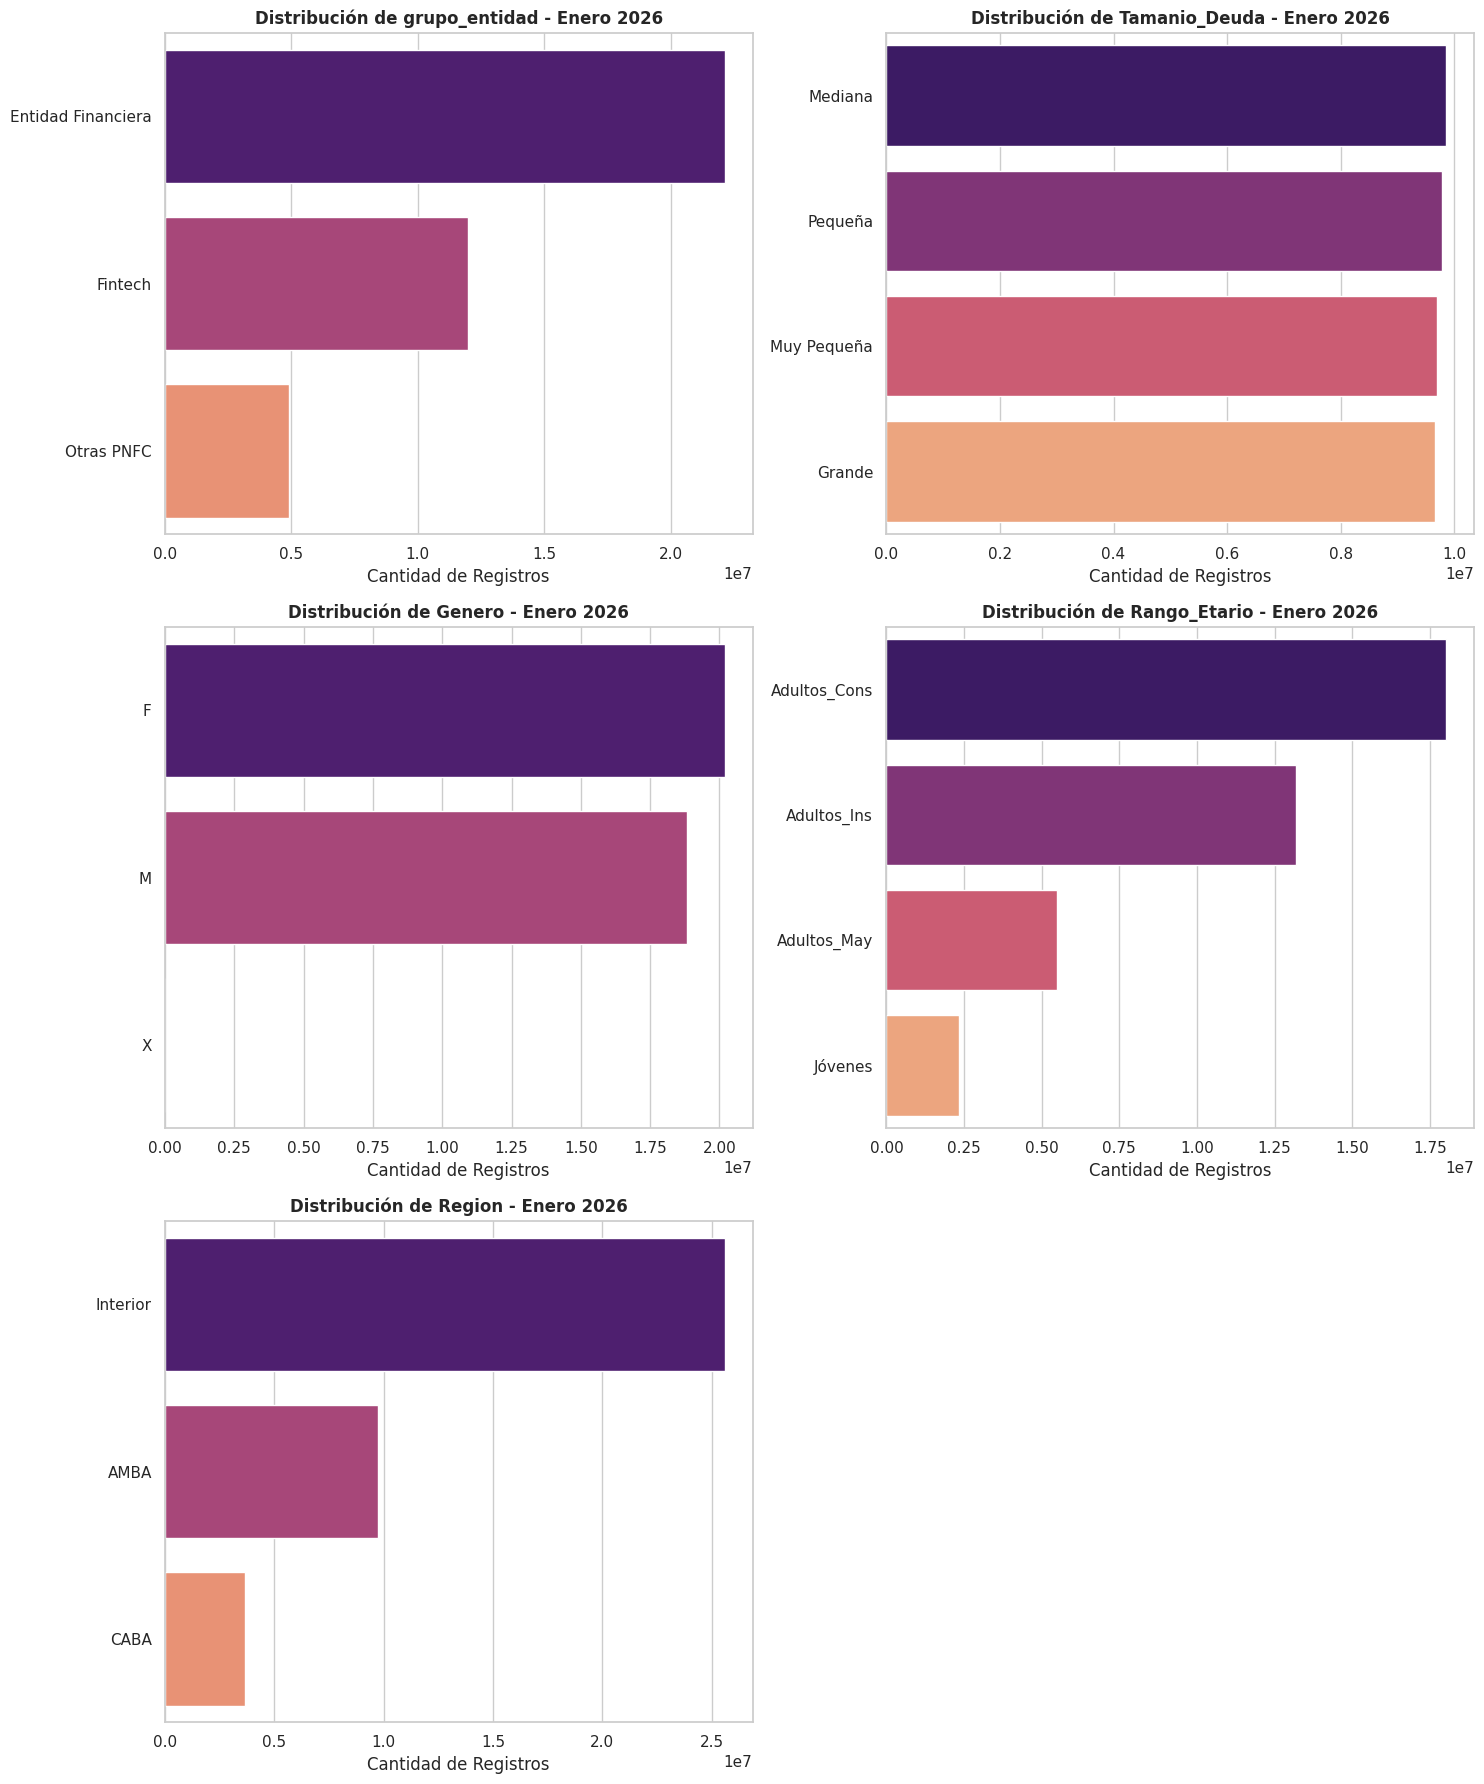

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

ruta_mca_final = '/content/drive/MyDrive/Tesis2026/df_mca_2026_final.parquet'

# Verificar y cargar el dataset si no está en memoria
if 'df_mca_2026' not in locals():
    if os.path.exists(ruta_mca_final):
        print("Cargando dataset consolidado desde Drive...")
        df_mca_2026 = pd.read_parquet(ruta_mca_final)
    else:
        print("Error: No se encontró el archivo consolidado en Drive. Por favor ejecuta la celda de Merge (Jr3KARMBXJEX) primero.")

if 'df_mca_2026' in locals():
    # Definir columnas para el análisis
    cols_categoricas = ['grupo_entidad', 'Tamanio_Deuda', 'Genero', 'Rango_Etario', 'Region']

    # Configuración de estilo
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(3, 2, figsize=(15, 18))
    axes = axes.flatten()

    print("Calculando frecuencias para los gráficos...")

    for i, col in enumerate(cols_categoricas):
        # OPTIMIZACIÓN: Calculamos frecuencias para no saturar RAM graficando filas crudas
        counts = df_mca_2026[col].value_counts().reset_index()
        counts.columns = [col, 'count']

        sns.barplot(y=col, x='count', data=counts,
                    ax=axes[i], palette='magma', hue=col, legend=False)

        axes[i].set_title(f'Distribución de {col} - Enero 2026', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Cantidad de Registros')
        axes[i].set_ylabel('')

    if len(axes) > len(cols_categoricas):
        fig.delaxes(axes[5])

    plt.tight_layout()
    plt.show()

# Celda 4: Múltiple Correspondencias (MCA)

Iniciando MCA con optimización de memoria (Sampling 10%)...
Modelo entrenado. Extrayendo coordenadas y frecuencias...


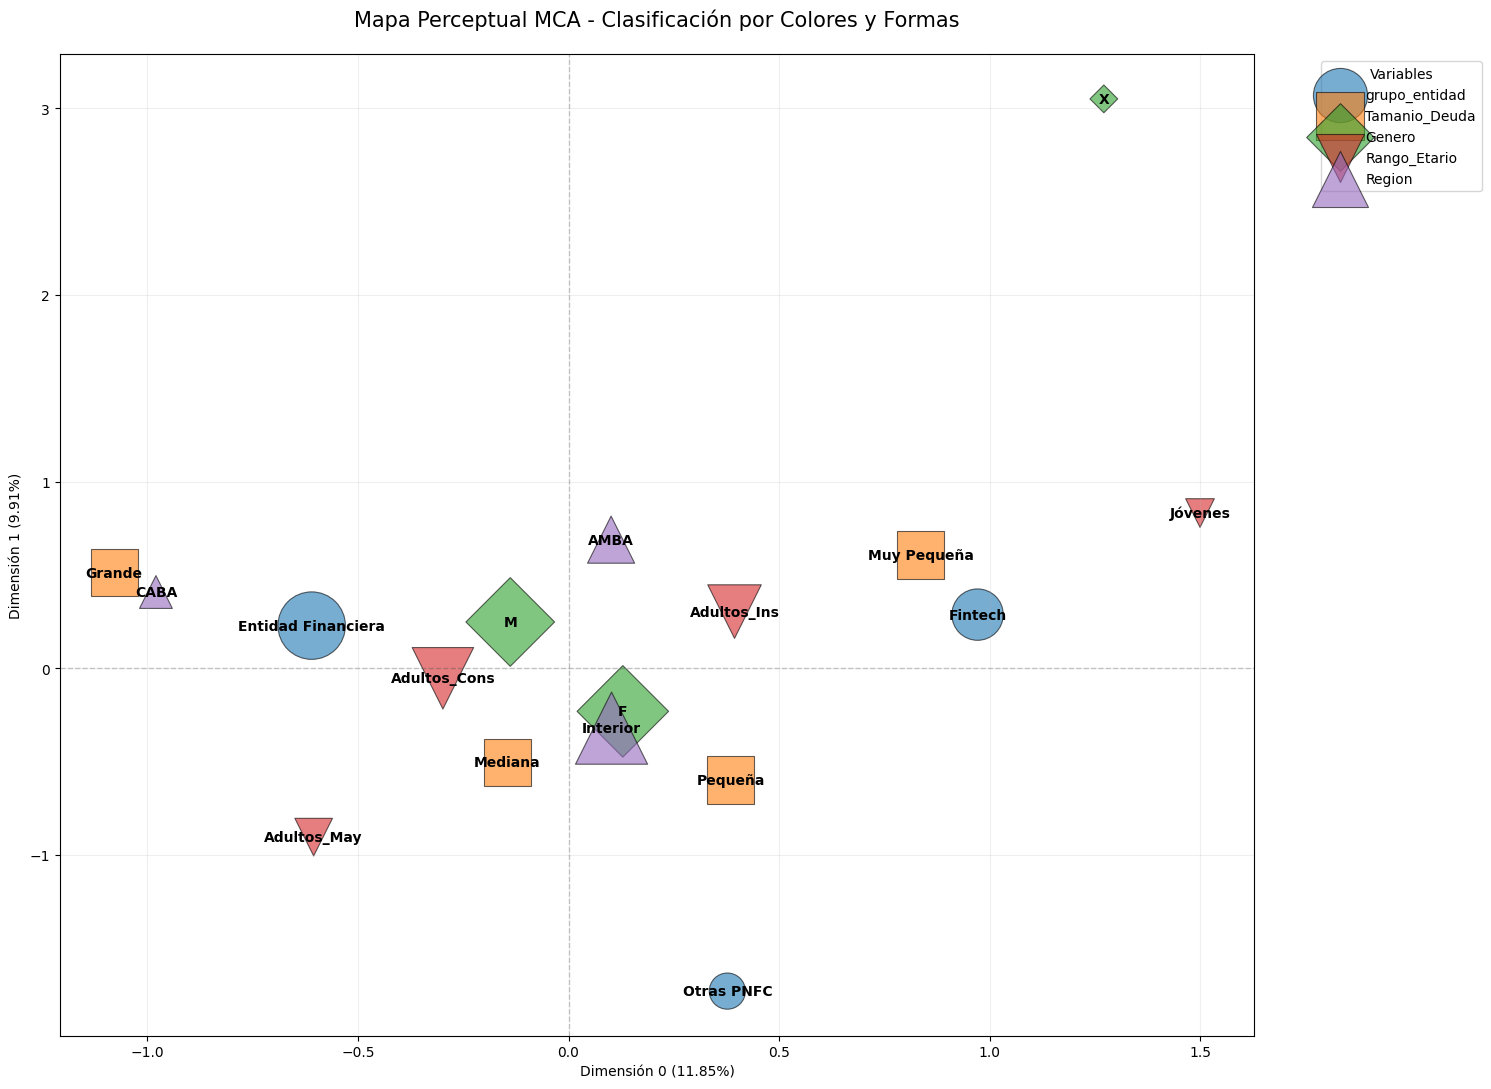

In [6]:
import prince
import matplotlib.pyplot as plt
import pandas as pd
import gc
import os

ruta_mca_final = '/content/drive/MyDrive/Tesis2026/df_mca_2026_final.parquet'

if 'df_mca_2026' not in locals():
    if os.path.exists(ruta_mca_final):
        df_mca_2026 = pd.read_parquet(ruta_mca_final)

if 'df_mca_2026' in locals():
    print("Iniciando MCA con optimización de memoria (Sampling 10%)...")
    df_sample = df_mca_2026.sample(frac=0.10, random_state=42)

    mca_26 = prince.MCA(n_components=2, n_iter=3, copy=False, engine='sklearn', random_state=42)
    mca_26 = mca_26.fit(df_sample)

    print("Modelo entrenado. Extrayendo coordenadas y frecuencias...")
    col_coords = mca_26.column_coordinates(df_sample)

    frecuencias_dict = {}
    for col in df_mca_2026.columns:
        val_counts = df_mca_2026[col].value_counts()
        for val, count in val_counts.items():
            frecuencias_dict[f"{col}__{val}"] = count

    palette = {'grupo_entidad': '#1f77b4', 'Tamanio_Deuda': '#ff7f0e', 'Genero': '#2ca02c', 'Rango_Etario': '#d62728', 'Region': '#9467bd'}
    markers = {'grupo_entidad': 'o', 'Tamanio_Deuda': 's', 'Genero': 'D', 'Rango_Etario': 'v', 'Region': '^'}

    plt.figure(figsize=(16, 12))

    for var_name in palette.keys():
        mask = [idx.startswith(f"{var_name}__") for idx in col_coords.index]
        subset = col_coords[mask]

        if not subset.empty:
            subset_counts = [frecuencias_dict.get(idx, 100) for idx in subset.index]
            max_total = max(frecuencias_dict.values())
            subset_sizes = [(c / max_total * 3000) + 300 for c in subset_counts]

            plt.scatter(subset[0], subset[1], s=subset_sizes, alpha=0.6,
                        color=palette[var_name], marker=markers[var_name],
                        label=var_name, edgecolors='black', linewidth=0.8)

            for idx in subset.index:
                label = idx.split('__')[-1]
                # Aumento de fontsize a 12 y desplazamiento para evitar solapamiento con el punto
                plt.annotate(label, (subset.loc[idx, 0], subset.loc[idx, 1]),
                             fontsize=12, fontweight='bold', ha='center', va='center',
                             bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.3))

    plt.axhline(0, color='black', lw=1, ls='--', alpha=0.2)
    plt.axvline(0, color='black', lw=1, ls='--', alpha=0.2)
    plt.title('Mapa Perceptual MCA - Optimizado (Sin Género X)', fontsize=18, pad=20)
    plt.xlabel(f'Dimensión 0 ({mca_26.percentage_of_variance_[0]:.2f}%)', fontsize=14)
    plt.ylabel(f'Dimensión 1 ({mca_26.percentage_of_variance_[1]:.2f}%)', fontsize=14)
    plt.legend(title="Variables", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    del df_sample
    gc.collect()

In [ ]:
import joblib

# Definir rutas de exportación
ruta_modelo = '/content/drive/MyDrive/Tesis2026/mca_model_2026.joblib'
ruta_coords = '/content/drive/MyDrive/Tesis2026/mca_coords_2026.parquet'

print("Exportando modelo MCA y coordenadas...")

# 1. Guardar el objeto del modelo (incluye autovalores y parámetros)
joblib.dump(mca_26, ruta_modelo)

# 2. Guardar las coordenadas de las columnas para recrear el gráfico rápidamente
col_coords.to_parquet(ruta_coords)

print(f"Modelo guardado en: {ruta_modelo}")
print(f"Coordenadas guardadas en: {ruta_coords}")